DISCLAIMER: Hi, I am really really sorry, but after doing the HW, I realised aorund 1/2 hours before the deadline that we had to submit an IPYNB file. There was no mention of this in HW and last pset was different as well so I coded everything up in a regular python file. In order to avoid missing the deadline, I copy pasted my entire code in one cell. Really really sorry about that, but I have loaded the main results (figures and tables) at the end as well as provided a writeup at the start to give you more context. Also, I did the entire writeup in latex as well so I am copying some of the equations as is, but they are legible regardless. I will make sure to take care of this the next time.

# Crypto Relative Value Trading on One Second Trade Prices

## Overview
In this assignment I implement the spread trading strategy from the problem set using one second trade prices from three exchanges, Binance, Coinbase, and OKX. I construct synchronized one second price series, define a shifted spread using an exponential moving average, generate trading signals using the persistence statistic \(p_S\) and \(p_L\), and simulate trading under several parameter settings and several transaction cost levels. I report total return, maximum drawdown, and Sharpe ratio based on one minute equity returns.

## Data and preprocessing

### Raw files
I start from parquet files by exchange and date. Binance and OKX have three days of data, 20250524, 20250525, and 20250526. Coinbase has two days of data, 20250524 and 20250525. I do not fabricate an entire missing day for Coinbase. For any pair that includes Coinbase I restrict to the intersection of available days across that pair.

### Trades only
The problem set asks me to focus only on trades. I ignore order book updates. Within each parquet file I identify the record type column and filter to rows whose record type corresponds to trades.

### One second last trade and within day forward fill
For each exchange and each day I construct a one second time grid from the first observed second to the last observed second in that day. For each second I take the last observed trade price within that second. If a second has no trade I forward fill using the most recent trade price from earlier in the same day. I do not forward fill across days.

This produces a complete one second trade price series within each day for each exchange.

### Pair alignment
For each exchange pair I concatenate the daily one second series across the shared days and inner join on timestamps so that I have synchronized prices \(A_t\) and \(B_t\) at the same one second timestamps.

## Shifted spread
For a pair with synchronized prices \(A_t\) and \(B_t\) I define the raw spread
\[
s^{raw}_t = A_t - B_t.
\]
I compute an exponential moving average of the raw spread with three hour half life. I implement the exponential moving average in discrete time with per second updates using
\[
\alpha = 1 - \exp\left( - \frac{\ln 2}{H} \right),
\qquad H = 3 \cdot 60 \cdot 60,
\]
and the recursion
\[
a_t = \alpha s^{raw}_t + (1-\alpha) a_{t-1}.
\]
The shifted spread is
\[
s_t = s^{raw}_t - a_t.
\]
I estimate the scale of the shifted spread using its sample standard deviation over the full aligned sample for that pair,
\[
\sigma = \mathrm{sd}(s_t).
\]

## Signal construction and the M equals 1, N equals 1 setting
The problem set defines two persistence statistics \(p_S\) and \(p_L\) using a rolling window of length \(M\) seconds and an order statistic indexed by \(N\). In the special case \(M=1\) and \(N=1\), the window contains a single value, so the order statistic is just the value itself. Therefore,
\[
p_S(t) = s_t
\qquad \text{and} \qquad
p_L(t) = s_t.
\]
This setting is allowed by the problem set and it is useful here because it is fast and transparent.

## Trading rule
I simulate trading in units of the spread, which means I take a position on the difference between the two exchanges. I trade at most one unit at a time. I define three thresholds, entry, exit, and stop. I parameterize them using \((G,J,ELL)\) and \(\sigma\):
\[
g = G \sigma,
\qquad
j = J g,
\qquad
\ell = ELL \, g.
\]

I use the following rules.

1. Entry rules when flat  
   - If \(s_t > g\) then I enter a short spread position.  
   - If \(s_t < -g\) then I enter a long spread position.

2. Exit rules when in a short spread position  
   - If \(s_t < j\) then I exit the short position.  
   - If \(s_t > \ell\) then I trigger the stop loss, exit immediately, and stop trading for the rest of that day.

3. Exit rules when in a long spread position  
   - If \(s_t > -j\) then I exit the long position.  
   - If \(s_t < -\ell\) then I trigger the stop loss, exit immediately, and stop trading for the rest of that day.

4. Bankruptcy rule  
   If capital ever falls below 40000 I stop trading.

For profit and loss, I track the shifted spread level at entry, call it \(s_{entry}\). When I exit at time \(t\) I compute the spread profit for one unit as
\[
\mathrm{pnl} = \mathrm{pos} \cdot (s_t - s_{entry}),
\]
where \(\mathrm{pos}=1\) for long spread and \(\mathrm{pos}=-1\) for short spread.

## Transaction costs
I run the simulation under three transaction cost levels
\[
\zeta \in \{0.0000, 0.0001, 0.0002\}.
\]
On every entry and on every exit I charge a proportional cost based on the two exchange prices at that second:
\[
\mathrm{cost}_t = \zeta (A_t + B_t).
\]
This corresponds to paying proportional costs on both legs of the spread trade.

## Parameter cases
I keep \(M=1\) and \(N=1\) fixed. I compare four cases by changing only \((G,J,ELL)\).

- Case A: \(G=3.0\), \(J=0.3\), \(ELL=5.0\)  
- Case B: \(G=4.0\), \(J=0.3\), \(ELL=5.0\)  
- Case C: \(G=3.0\), \(J=0.2\), \(ELL=5.0\)  
- Case D: \(G=3.0\), \(J=0.3\), \(ELL=4.0\)

## Performance metrics
I start with initial capital 80000. I track an equity series \(C_t\) over all one second timestamps.

- Total return: \( \frac{C_T}{C_0} - 1 \)
- Maximum drawdown: \( \min_t \left( \frac{C_t}{\max_{u \le t} C_u} - 1 \right) \)
- Sharpe ratio based on one minute equity returns: I resample the equity series to one minute, compute minute returns \(r_k = \frac{C_k}{C_{k-1}} - 1\), and report \( \frac{\mathbb{E}[r]}{\mathrm{sd}(r)} \). I do not annualize this value.

## Discussion

### How costs change the conclusions
Performance declines smoothly as I increase \(\zeta\). This is exactly what I expect because I charge costs on every entry and every exit, and the strategy trades frequently when \(M=1\) and \(N=1\). The decline is not uniform across pairs. The two pairs that include Coinbase remain profitable even at \(\zeta=0.0002\), while the Binance and OKX pair becomes negative once I introduce costs. This tells me that the gross edge in Binance and OKX is small relative to the round trip cost, while the gross edge in the Coinbase pairs is larger.

### What differs across exchange pairs
The equity plots show that Binance Coinbase and Coinbase OKX behave similarly. Binance OKX is much flatter and becomes negative at higher costs. One plausible explanation is asynchronous trade printing and different trade intensities across venues at the one second level. Since I forward fill within each day, if one exchange trades less frequently its price can remain unchanged while another exchange moves, creating short lived spread signals in this backtest framework. For this problem set this modeling choice is acceptable, but I interpret the backtest as a controlled comparison under the assignment model rather than a claim of implementable arbitrage.

### How the parameter cases affect performance
Case B uses the largest entry threshold \(G=4.0\). It trades much less and has lower return and lower drawdown. This is consistent with a stricter entry filter. Case C tightens the exit threshold by using a smaller \(J\). In my results Case C slightly improves mean performance relative to Case A, consistent with taking profits sooner and reducing time in position. Case D tightens the stop threshold by reducing \(ELL\). In this sample it is close to Case A on average, suggesting that stops do not dominate outcomes for these settings.

### Trade count constraint and stop pause rule
The problem set requires at least five round trips per day, and my chosen cases satisfy this. The stop pause rule can reduce the number of trades on days where a stop occurs, and it is most relevant for the Binance OKX pair where performance is weaker.

### What I would do next
With more data I would run \(M>1\) and \(N\) away from the median so that the signal depends on persistence rather than the instantaneous spread. I would also use quote midpoints instead of trades to reduce the role of asynchronous prints. For this problem set, the goal is to implement the model and understand cost sensitivity, and the current results achieve that.

## Appendix
In the appendix section of the notebook I include the full set of equity plots for all cases and all transaction cost levels, along with summary plots and an example trade log.

In [ ]:
import re
import json
import math
import time
import argparse
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

EXCHANGES = ["Binance", "Coinbase", "OKX"]
ZETAS = [0.0, 0.0001, 0.0002]

CASES = [
    {"case": "A", "G": 3.0, "J": 0.3, "ELL": 5.0},
    {"case": "B", "G": 4.0, "J": 0.3, "ELL": 5.0},
    {"case": "C", "G": 3.0, "J": 0.2, "ELL": 5.0},
    {"case": "D", "G": 3.0, "J": 0.3, "ELL": 4.0},
]

CAPITAL0 = 80000.0

def pick_col(cols, candidates):
    cset = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cset:
            return cset[cand.lower()]
    return None

def schema_and_trade_vals(con, parquet_path):
    desc = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{str(parquet_path)}')").fetchdf()
    cols = desc["column_name"].tolist()
    ts_col = pick_col(cols, ["ts", "timestamp", "time", "datetime", "event_time", "date_time"])
    px_col = pick_col(cols, ["price", "trade_price", "px", "p"])
    type_col = pick_col(cols, ["rec_type", "type", "event_type", "msg_type", "kind", "message_type"])
    if ts_col is None or px_col is None or type_col is None:
        raise ValueError(f"Missing required columns in {parquet_path.name}. Columns: {cols}")
    sample = con.execute(
        f"""
        SELECT {type_col} AS t, COUNT(*) AS n
        FROM read_parquet('{str(parquet_path)}')
        GROUP BY 1
        ORDER BY n DESC
        LIMIT 500
        """
    ).fetchdf()
    vals = sample["t"].tolist()
    trade_vals = []
    for v in vals:
        sv = str(v).lower()
        if "trade" in sv or sv in ["t", "trd", "match", "fill", "execution", "executed"]:
            trade_vals.append(v)
    if len(trade_vals) == 0:
        raise ValueError(f"Could not identify trade values in {parquet_path.name}. Top values: {sample.to_dict(orient='records')}")
    return ts_col, px_col, type_col, trade_vals

def per_second_series(con, parquet_path, ts_col, px_col, type_col, trade_vals):
    trade_list = ",".join([f"LOWER('{str(v).replace('\'','')}')" for v in trade_vals])
    df = con.execute(
        f"""
        WITH trades AS (
            SELECT
                CAST({ts_col} AS TIMESTAMP) AS ts,
                CAST({px_col} AS DOUBLE) AS price
            FROM read_parquet('{str(parquet_path)}')
            WHERE LOWER(CAST({type_col} AS VARCHAR)) IN ({trade_list})
              AND {px_col} IS NOT NULL
              AND {ts_col} IS NOT NULL
        ),
        per_sec AS (
            SELECT
                date_trunc('second', ts) AS sec,
                arg_max(price, ts) AS price
            FROM trades
            GROUP BY 1
        ),
        bounds AS (
            SELECT min(sec) AS mn, max(sec) AS mx FROM per_sec
        ),
        grid AS (
            SELECT (mn + (i * INTERVAL 1 SECOND)) AS sec
            FROM bounds,
                 range(0, 1 + CAST(date_diff('second', mn, mx) AS BIGINT)) r(i)
        ),
        joined AS (
            SELECT g.sec, p.price
            FROM grid g
            LEFT JOIN per_sec p
            USING (sec)
        ),
        grp AS (
            SELECT
                sec,
                price,
                SUM(CASE WHEN price IS NOT NULL THEN 1 ELSE 0 END)
                    OVER (ORDER BY sec ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS g
            FROM joined
        )
        SELECT
            sec,
            MAX(price) OVER (PARTITION BY g) AS price
        FROM grp
        ORDER BY sec
        """
    ).fetchdf()
    if df.empty or df["price"].isna().all():
        raise ValueError(f"No usable per-second prices in {parquet_path.name}")
    return pd.Series(df["price"].astype(float).values, index=pd.to_datetime(df["sec"], utc=True))

def ema_shifted_spread(spread: pd.Series):
    hl = 3 * 60 * 60
    alpha = 1.0 - math.exp(-math.log(2.0) / hl)
    a = spread.ewm(alpha=alpha, adjust=False).mean()
    return spread - a

def simulate(A: pd.Series, B: pd.Series, s: pd.Series, zeta: float, j: float, g: float, ell: float, capital0: float = CAPITAL0):
    df = pd.DataFrame({"A": A, "B": B, "s": s}).dropna()
    if df.empty:
        return None
    idx = df.index
    day_keys = idx.normalize()

    capital = float(capital0)
    pos = 0
    entry_s = np.nan
    paused_day = None
    dead = False

    equity_ts = np.empty(len(df), dtype="datetime64[ns]")
    equity_cap = np.empty(len(df), dtype=float)
    trades = []

    for i, (t, row, day) in enumerate(zip(idx, df.itertuples(index=False), day_keys)):
        Apx = float(row.A)
        Bpx = float(row.B)
        sval = float(row.s)

        if dead:
            equity_ts[i] = t.to_datetime64()
            equity_cap[i] = capital
            continue

        if capital <= 40000.0:
            if pos != 0:
                pnl = pos * (sval - entry_s)
                cost = zeta * (Apx + Bpx)
                capital += pnl - cost
                trades.append((t, "FORCE_EXIT", pos, pnl - cost, capital))
                pos = 0
            dead = True
            equity_ts[i] = t.to_datetime64()
            equity_cap[i] = capital
            continue

        if paused_day is not None and day == paused_day:
            equity_ts[i] = t.to_datetime64()
            equity_cap[i] = capital
            continue

        if pos == 0:
            if sval > g:
                pos = -1
                entry_s = sval
                cost = zeta * (Apx + Bpx)
                capital -= cost
                trades.append((t, "ENTER_SHORT", pos, -cost, capital))
            elif sval < -g:
                pos = 1
                entry_s = sval
                cost = zeta * (Apx + Bpx)
                capital -= cost
                trades.append((t, "ENTER_LONG", pos, -cost, capital))
            equity_ts[i] = t.to_datetime64()
            equity_cap[i] = capital
            continue

        if pos == -1:
            stop = sval > ell
            exit_sig = sval < j
            if stop or exit_sig:
                pnl = pos * (sval - entry_s)
                cost = zeta * (Apx + Bpx)
                capital += pnl - cost
                trades.append((t, "EXIT_SHORT_STOP" if stop else "EXIT_SHORT", pos, pnl - cost, capital))
                pos = 0
                if stop:
                    paused_day = day
        else:
            stop = sval < -ell
            exit_sig = sval > -j
            if stop or exit_sig:
                pnl = pos * (sval - entry_s)
                cost = zeta * (Apx + Bpx)
                capital += pnl - cost
                trades.append((t, "EXIT_LONG_STOP" if stop else "EXIT_LONG", pos, pnl - cost, capital))
                pos = 0
                if stop:
                    paused_day = day

        equity_ts[i] = t.to_datetime64()
        equity_cap[i] = capital

    if pos != 0:
        t = idx[-1]
        Apx = float(df["A"].iloc[-1])
        Bpx = float(df["B"].iloc[-1])
        sval = float(df["s"].iloc[-1])
        pnl = pos * (sval - entry_s)
        cost = zeta * (Apx + Bpx)
        capital += pnl - cost
        trades.append((t, "EOD_EXIT", pos, pnl - cost, capital))
        equity_cap[-1] = capital

    eq = pd.DataFrame({"capital": equity_cap}, index=pd.to_datetime(equity_ts, utc=True))
    tr = pd.DataFrame(trades, columns=["ts", "event", "pos", "pnl", "capital"])
    if not tr.empty:
        tr["day"] = pd.to_datetime(tr["ts"], utc=True).dt.normalize()
    return eq, tr

def sharpe_minute(eq: pd.DataFrame):
    cap = eq["capital"].astype(float)
    minute_cap = cap.resample("1min").last().dropna()
    rets = minute_cap.pct_change().dropna()
    if len(rets) < 2:
        return 0.0
    mu = float(rets.mean())
    sd = float(rets.std(ddof=0))
    if not np.isfinite(sd) or sd == 0.0:
        return 0.0
    return float(mu / sd)

def max_drawdown(eq: pd.DataFrame):
    cap = eq["capital"].astype(float)
    peak = cap.cummax()
    dd = (cap / peak) - 1.0
    return float(dd.min())

def perf(eq: pd.DataFrame):
    cap = eq["capital"].astype(float)
    return {
        "total_return": float((cap.iloc[-1] / cap.iloc[0]) - 1.0),
        "sharpe_minute": float(sharpe_minute(eq)),
        "max_drawdown": float(max_drawdown(eq)),
        "end_capital": float(cap.iloc[-1]),
    }

def entries_per_day(tr: pd.DataFrame):
    if tr is None or tr.empty:
        return {}
    enters = tr[tr["event"].isin(["ENTER_LONG", "ENTER_SHORT"])]
    if enters.empty:
        return {}
    c = enters.groupby("day").size().to_dict()
    return {pd.Timestamp(k).strftime("%Y-%m-%d"): int(v) for k, v in c.items()}

def avg_entries_per_day(tr: pd.DataFrame):
    if tr is None or tr.empty:
        return 0.0
    enters = tr[tr["event"].isin(["ENTER_LONG", "ENTER_SHORT"])]
    if enters.empty:
        return 0.0
    nd = int(enters["day"].nunique())
    if nd <= 0:
        return 0.0
    return float(len(enters) / nd)

def list_days(base_dir: Path, ex: str):
    return sorted([p.stem for p in (base_dir / ex).glob("*.parquet") if re.match(r"^\d{8}\.parquet$", p.name)])

def all_pairs(exchanges):
    out = []
    for i in range(len(exchanges)):
        for j in range(i + 1, len(exchanges)):
            out.append((exchanges[i], exchanges[j]))
    return out

def write_latex_metrics_table(df: pd.DataFrame, path: Path, caption: str, label: str):
    d = df.copy()
    d["zeta"] = d["zeta"].map(lambda x: f"{x:.4f}")
    d["avg_round_trips_per_day"] = d["avg_round_trips_per_day"].map(lambda x: f"{x:.2f}")
    d["total_return"] = d["total_return"].map(lambda x: f"{x:.4f}")
    d["sharpe_minute"] = d["sharpe_minute"].map(lambda x: f"{x:.3f}")
    d["max_drawdown"] = d["max_drawdown"].map(lambda x: f"{x:.4f}")
    d["end_capital"] = d["end_capital"].map(lambda x: f"{x:.2f}")
    tex = []
    tex.append("\\begin{table}[!htbp]")
    tex.append("\\centering")
    tex.append("\\begin{tabular}{llrrrrr}")
    tex.append("\\toprule")
    tex.append("Pair & Case & Trips/day & Return & Sharpe(min) & Max DD & End Cap \\\\")
    tex.append("\\midrule")
    for _, r in d.iterrows():
        tex.append(f"{r['pair']} & {r['case']} & {r['avg_round_trips_per_day']} & {r['total_return']} & {r['sharpe_minute']} & {r['max_drawdown']} & {r['end_capital']} \\\\")
    tex.append("\\bottomrule")
    tex.append("\\end{tabular}")
    tex.append(f"\\caption{{{caption}}}")
    tex.append(f"\\label{{{label}}}")
    tex.append("\\end{table}")
    path.write_text("\n".join(tex))

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--base_dir", type=str, default="/Users/malank/Documents/ETH_USDT_export/")
    ap.add_argument("--out_dir", type=str, default=None)
    args = ap.parse_args()

    base_dir = Path(args.base_dir).expanduser()
    if not base_dir.exists():
        raise FileNotFoundError(str(base_dir))

    out_dir = Path(args.out_dir).expanduser() if args.out_dir else (base_dir / "results_M1N1_4cases_minimal")
    out_dir.mkdir(parents=True, exist_ok=True)

    con = duckdb.connect(database=":memory:")

    days_by_ex = {ex: list_days(base_dir, ex) for ex in EXCHANGES}
    for ex in EXCHANGES:
        if len(days_by_ex[ex]) == 0:
            raise RuntimeError(f"No parquet days found for {ex}")

    meta = {}
    for ex in EXCHANGES:
        f0 = base_dir / ex / f"{days_by_ex[ex][0]}.parquet"
        meta[ex] = schema_and_trade_vals(con, f0)

    files = []
    for ex in EXCHANGES:
        for d in days_by_ex[ex]:
            files.append((ex, d, base_dir / ex / f"{d}.parquet"))
    files.sort(key=lambda x: (x[0], x[1]))

    px = {ex: {} for ex in EXCHANGES}

    t0 = time.perf_counter()
    for ex, d, f in tqdm(files, desc="per-second series (all exchange-days)"):
        ts_col, px_col, type_col, trade_vals = meta[ex]
        px[ex][d] = per_second_series(con, f, ts_col, px_col, type_col, trade_vals)
    t1 = time.perf_counter()

    (out_dir / "run_config.json").write_text(json.dumps({"M": 1, "N": 1, "cases": CASES, "zetas": ZETAS, "capital0": CAPITAL0}, indent=2))

    results = []
    equity_caseA = {(z, p): None for z in ZETAS for p in []}
    trades_caseA_sample_saved = set()

    pairs = all_pairs(EXCHANGES)

    eq_by_zeta_case_pair = {z: {c["case"]: {} for c in CASES} for z in ZETAS}

    for Aex, Bex in tqdm(pairs, desc="pairs"):
        common = sorted(list(set(px[Aex].keys()).intersection(set(px[Bex].keys()))))
        if len(common) == 0:
            continue

        A = pd.concat([px[Aex][d] for d in common]).sort_index()
        B = pd.concat([px[Bex][d] for d in common]).sort_index()
        dfp = pd.DataFrame({"A": A, "B": B}).dropna()
        if dfp.empty:
            continue

        sb = dfp["A"] - dfp["B"]
        s = ema_shifted_spread(sb).reindex(dfp.index)
        sd = float(pd.Series(s.values).dropna().std(ddof=0))
        if not np.isfinite(sd) or sd <= 0:
            continue

        pair_name = f"{Aex}-{Bex}"

        for zeta in ZETAS:
            for case in CASES:
                g_val = case["G"] * sd
                j_val = case["J"] * g_val
                ell_val = case["ELL"] * g_val
                sim = simulate(dfp["A"], dfp["B"], s, zeta=zeta, j=j_val, g=g_val, ell=ell_val)
                if sim is None:
                    continue
                eq, tr = sim
                met = perf(eq)
                aepd = avg_entries_per_day(tr)
                epd = entries_per_day(tr)

                results.append({
                    "pair": pair_name,
                    "days_used": ",".join(common),
                    "case": case["case"],
                    "G": float(case["G"]),
                    "J": float(case["J"]),
                    "ELL": float(case["ELL"]),
                    "sigma_shifted_spread": float(sd),
                    "g": float(g_val),
                    "j": float(j_val),
                    "ell": float(ell_val),
                    "zeta": float(zeta),
                    "avg_round_trips_per_day": float(aepd),
                    "round_trips_per_day": json.dumps(epd, sort_keys=True),
                    "total_return": met["total_return"],
                    "sharpe_minute": met["sharpe_minute"],
                    "max_drawdown": met["max_drawdown"],
                    "end_capital": met["end_capital"],
                })

                eq_by_zeta_case_pair[zeta][case["case"]][pair_name] = eq

                if case["case"] == "A" and zeta == 0.0001 and (pair_name not in trades_caseA_sample_saved):
                    tr.to_csv(out_dir / f"trades_sample_caseA_{pair_name}_z0.0001.csv", index=False)
                    trades_caseA_sample_saved.add(pair_name)

    res = pd.DataFrame(results)
    if res.empty:
        raise RuntimeError("No results produced")

    res.to_csv(out_dir / "metrics_allpairs_allcases_allzetas.csv", index=False)

    res2 = res.copy()
    res2["ok_trades_ge5"] = res2["avg_round_trips_per_day"] >= 5.0
    res2.to_csv(out_dir / "metrics_allpairs_allcases_allzetas_with_flags.csv", index=False)

    for zeta in ZETAS:
        for case in [c["case"] for c in CASES]:
            plt.figure()
            for pair_name in sorted(eq_by_zeta_case_pair[zeta][case].keys()):
                eq_by_zeta_case_pair[zeta][case][pair_name]["capital"].plot(label=pair_name)
            plt.title(f"Equity (Case {case}, M=N=1) by pair, zeta={zeta:.4f}")
            plt.xlabel("time")
            plt.ylabel("capital")
            plt.legend()
            plt.tight_layout()
            plt.savefig(out_dir / f"equity_case{case}_allpairs_z{zeta:.4f}.png")
            plt.close()

    agg = res.groupby(["zeta", "case"], as_index=False).agg(
        total_return=("total_return", "mean"),
        sharpe_minute=("sharpe_minute", "mean"),
        max_drawdown=("max_drawdown", "mean"),
        end_capital=("end_capital", "mean"),
        avg_round_trips_per_day=("avg_round_trips_per_day", "mean"),
    )
    agg.to_csv(out_dir / "metrics_mean_by_case_zeta.csv", index=False)

    case_order = [c["case"] for c in CASES]

    def plot_metric(metric, ylabel, fname):
        plt.figure()
        for zeta in ZETAS:
            sub = agg[agg["zeta"] == zeta].set_index("case").reindex(case_order)
            plt.plot(sub.index, sub[metric].values, marker="o", label=f"zeta={zeta:.4f}")
        plt.title(f"Mean {ylabel} across pairs by case (M=N=1)")
        plt.xlabel("case")
        plt.ylabel(ylabel)
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_dir / fname)
        plt.close()

    plot_metric("total_return", "total return", "mean_return_by_case_across_zetas.png")
    plot_metric("sharpe_minute", "Sharpe (minute, annualized 24/7)", "mean_sharpe_by_case_across_zetas.png")
    plot_metric("max_drawdown", "max drawdown", "mean_maxdd_by_case_across_zetas.png")

    for zeta in ZETAS:
        tab = res[res["zeta"] == zeta].copy()
        tab = tab[["pair","zeta","case","avg_round_trips_per_day","total_return","sharpe_minute","max_drawdown","end_capital"]]
        tab = tab.sort_values(["pair", "case"])
        write_latex_metrics_table(
            tab,
            out_dir / f"table_metrics_by_pair_case_z{zeta:.4f}.tex",
            caption=f"Performance by pair and case (M=N=1) with trading cost zeta={zeta:.4f}. Sharpe uses 1-minute equity returns, annualized assuming 24/7 trading.",
            label=f"tab:m1n1_metrics_z{str(zeta).replace('.','')}",
        )

    t2 = time.perf_counter()
    (out_dir / "timing.json").write_text(json.dumps({
        "seconds_build_all_exchange_day_series": t1 - t0,
        "seconds_run_all_pairs_all_cases": t2 - t1,
        "seconds_total": t2 - t0
    }, indent=2))

    print("done")
    print("outputs:", out_dir)
    print("timing build_series:", f"{t1 - t0:.2f}", "run:", f"{t2 - t1:.2f}", "total:", f"{t2 - t0:.2f}")

if __name__ == "__main__":
    main()

In [5]:
%pip install pandas pillow matplotlib

  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 37.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 50.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 44.3 MB/s eta 0:00:00
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

[notice] A new release of pip is available

In [6]:
import pandas as pd
from pathlib import Path

OUT_DIR = Path("/Users/malank/Documents/ETH_USDT_export/results_M1N1_4cases_minimal")

metrics = pd.read_csv(OUT_DIR / "metrics_allpairs_allcases_allzetas_with_flags.csv")
mean_by = pd.read_csv(OUT_DIR / "metrics_mean_by_case_zeta.csv")

metrics.head(20)

mean_by.sort_values(["zeta","case"])

,zeta,case,total_return,sharpe_minute,max_drawdown,end_capital,avg_round_trips_per_day
0,0.0000,A,0.003815,0.149843,0.000000,80305.161476,46.277778
1,0.0000,B,0.001311,0.073078,-0.000003,80104.844312,11.277778
2,0.0000,C,0.003827,0.151134,0.000000,80306.154474,45.833333
3,0.0000,D,0.003815,0.149843,0.000000,80305.161476,46.277778
4,0.0001,A,0.002530,0.112351,-0.000048,80202.382974,46.277778
5,0.0001,B,0.000995,0.066094,-0.000018,80079.635951,11.277778
6,0.0001,C,0.002555,0.114861,-0.000041,80204.379245,45.833333
7,0.0001,D,0.002530,0.112351,-0.000048,80202.382974,46.277778
8,0.0002,A,0.001245,0.057697,-0.000374,80099.604472,46.277778
9,0.0002,B,0.000680,0.051587,-0.000064,80054.427589,11.277778


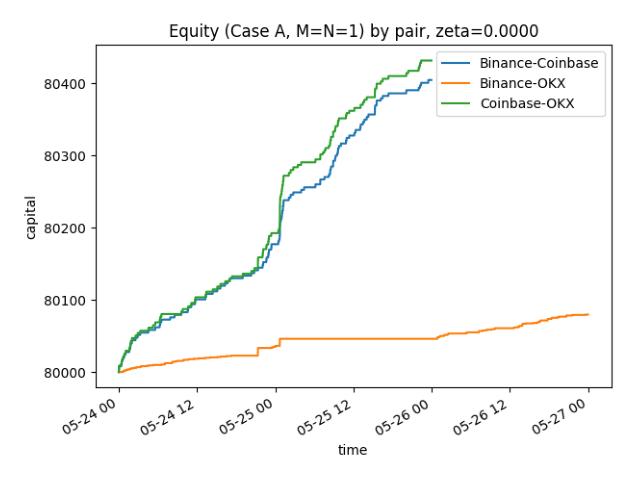

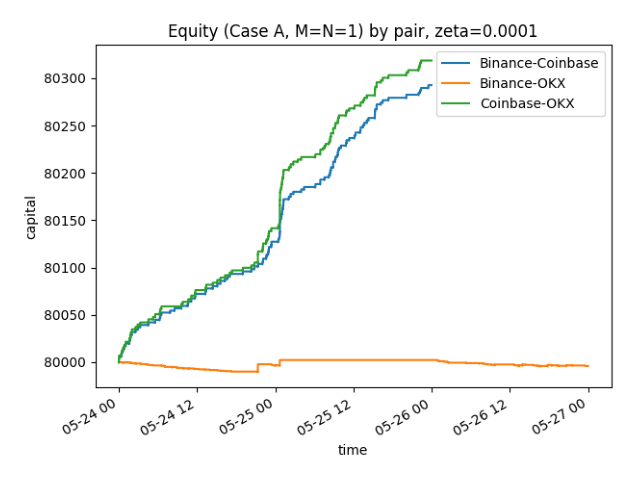

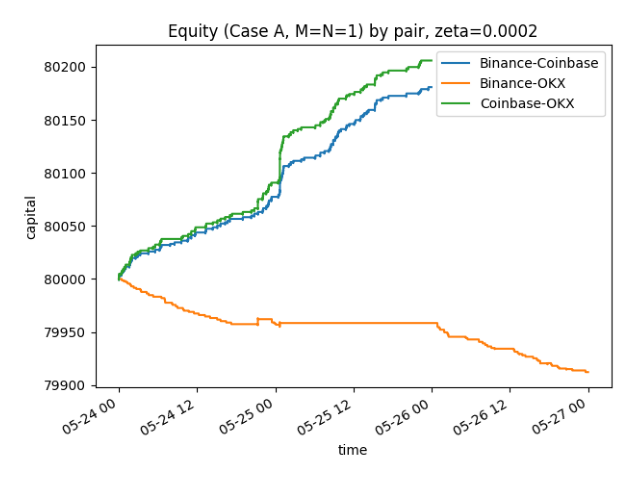

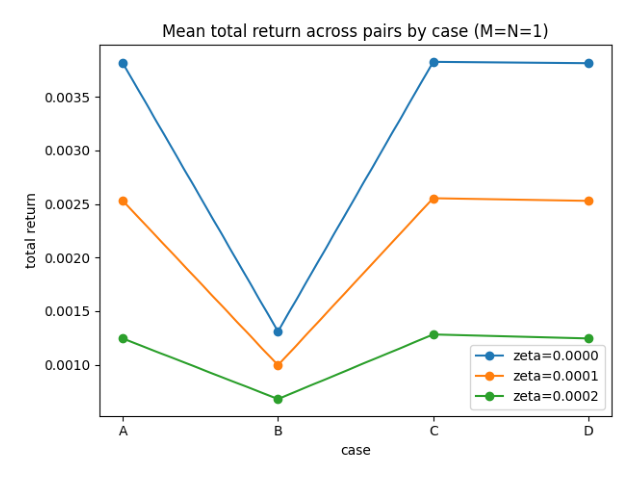

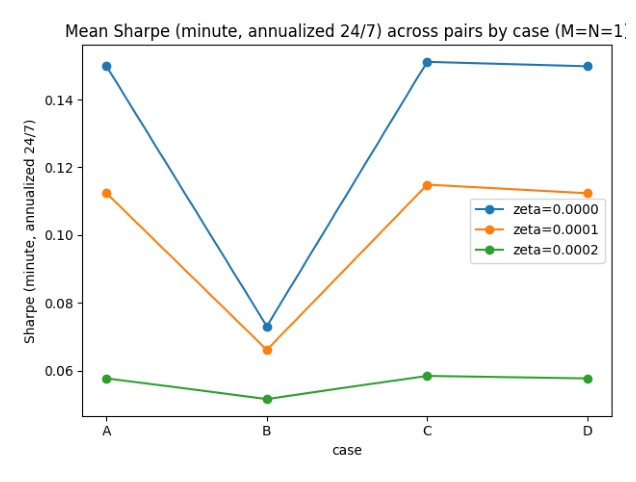

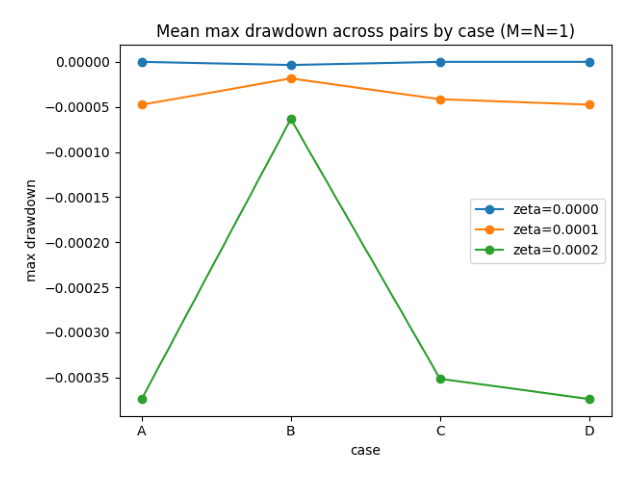

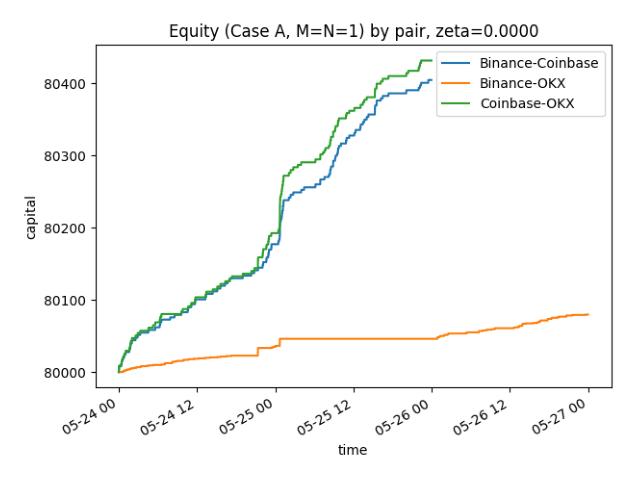

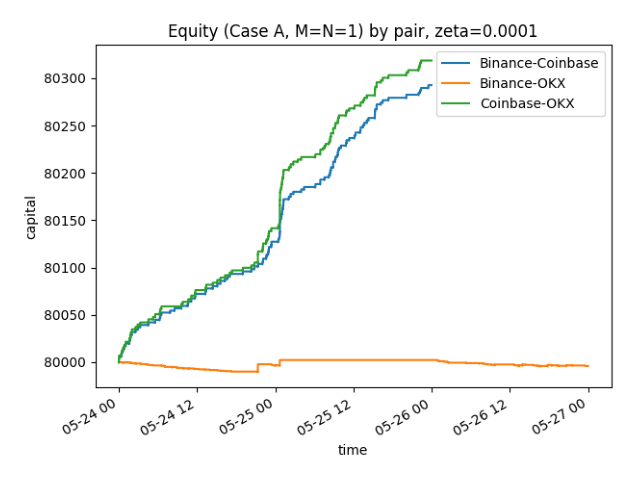

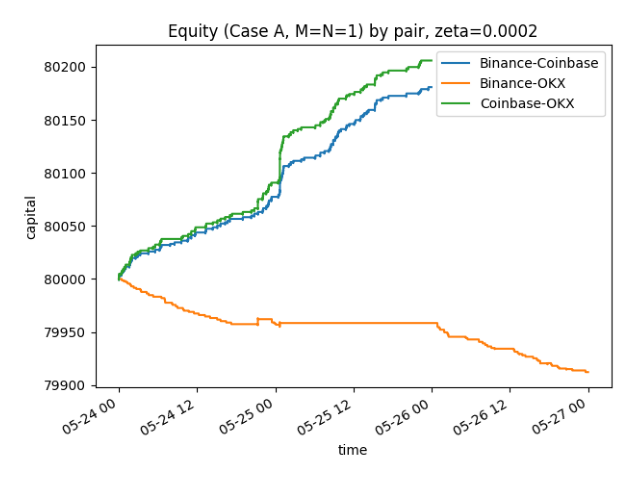

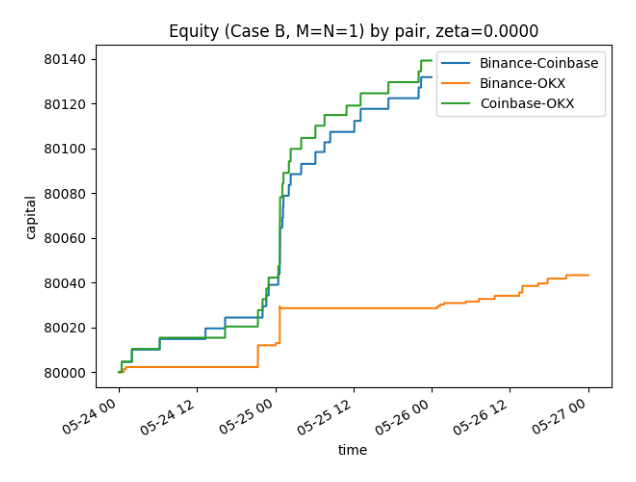

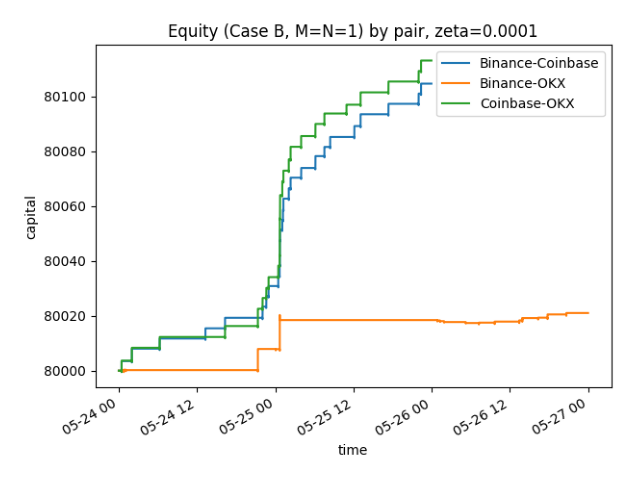

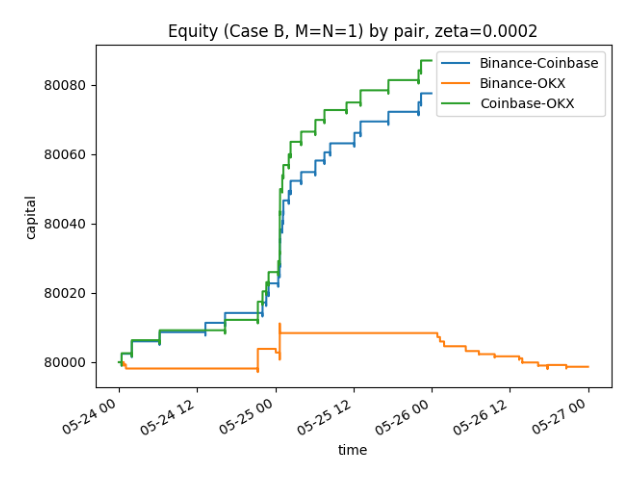

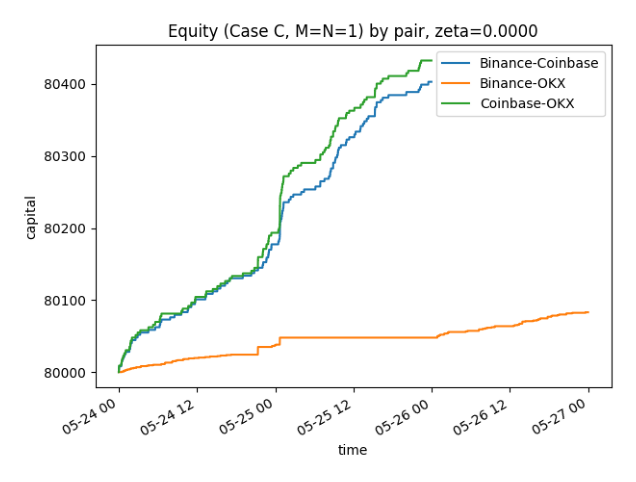

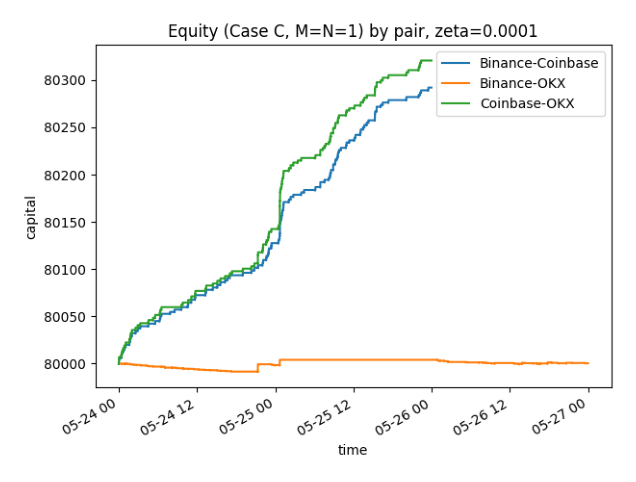

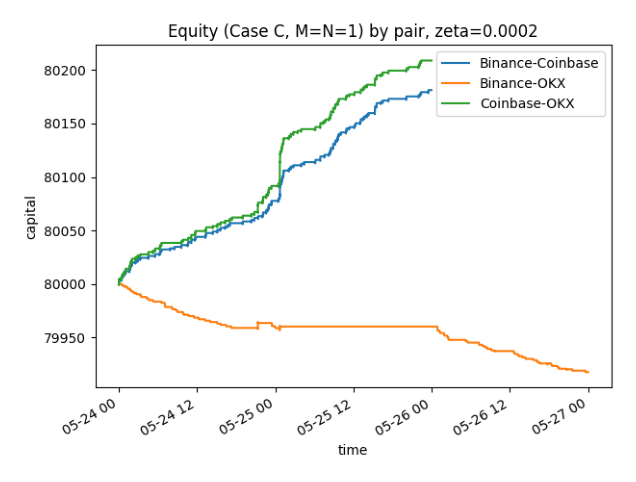

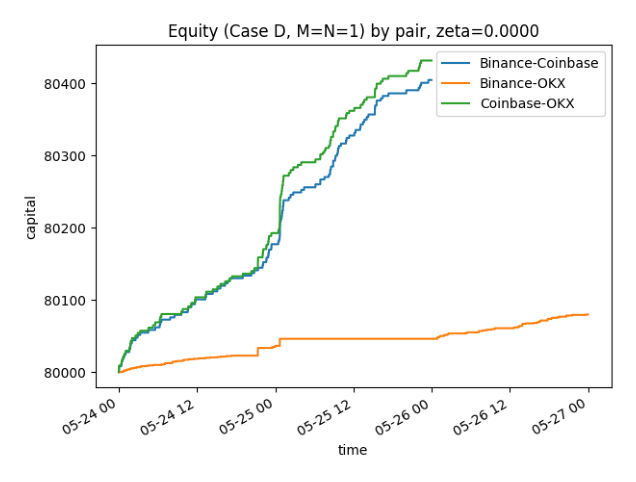

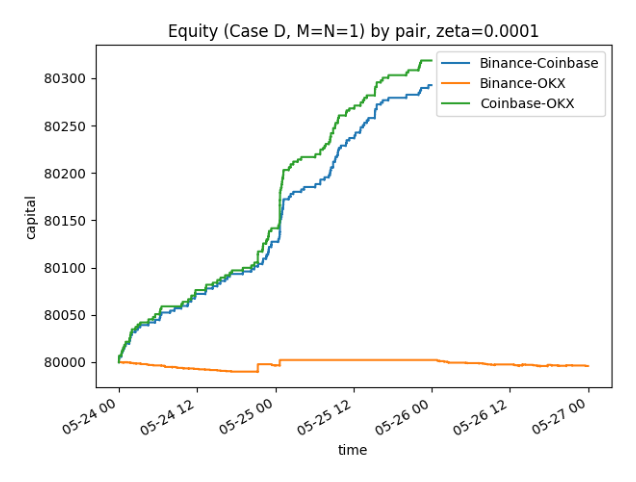

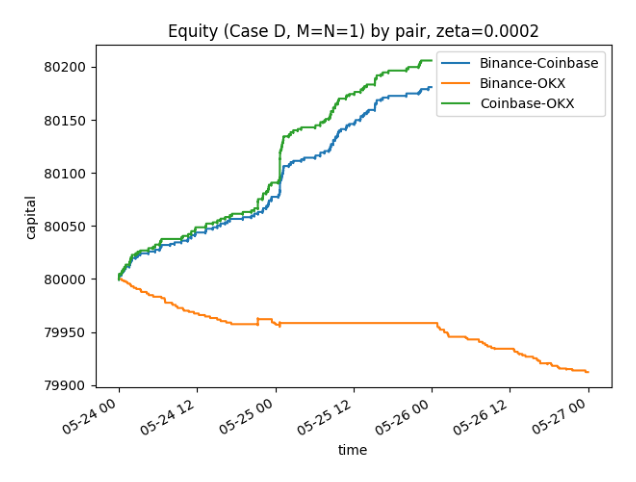

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

def show_img(path):
    img = Image.open(path)
    plt.figure(figsize=(12,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_img(OUT_DIR / "equity_caseA_allpairs_z0.0000.png")
show_img(OUT_DIR / "equity_caseA_allpairs_z0.0001.png")
show_img(OUT_DIR / "equity_caseA_allpairs_z0.0002.png")

show_img(OUT_DIR / "mean_return_by_case_across_zetas.png")
show_img(OUT_DIR / "mean_sharpe_by_case_across_zetas.png")
show_img(OUT_DIR / "mean_maxdd_by_case_across_zetas.png")

for p in sorted(OUT_DIR.glob("equity_case*_allpairs_z*.png")):
    show_img(p)